# Size optimization of a lattice

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/truss/size.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/truss/size.ipynb)

A hexahedral mesh of a bracket is converted into a lattice of bar elements. The cross-sectional areas of the bars are optimized to minimize the sum of compliances under two load cases at a fixed material volume.

In [1]:
import matplotlib.pyplot as plt
import meshio
import torch
from scipy.optimize import bisect
from tqdm import tqdm

from torchfem import Truss
from torchfem.data import get_data
from torchfem.materials import IsotropicElasticity1D
from torchfem.mesh import mesh_to_lattice

torch.set_default_dtype(torch.float64)

# Material
material = IsotropicElasticity1D(E=70000.0)

## Lattice

The mesh is read from an Abaqus input file shipped with torch-fem. `mesh_to_lattice` places a bar along every element edge and, with the `"cross"` variant, adds both diagonals of every element face. 

The `temp_left` node set of the input file holds the nodes of the flat face, which are clamped here. Both load cases act on the arm tip given by the `temp_right` node set: one along $y$ and one along the thin $z$ direction of the bracket. Each is stored as a separate nodal force tensor.

In [2]:
# Convert the hexahedral mesh to a lattice of bars
mesh = meshio.read(get_data("extruded_hex_mesh.inp"))
hexes = torch.tensor(mesh.cells_dict["hexahedron"])
nodes, bars = mesh_to_lattice(torch.tensor(mesh.points), hexes, "cross")

# Lattice model
lattice = Truss(nodes, bars, material)

# Clamp the flat face
lattice.constraints[mesh.point_sets["temp_left"]] = True

# Total force per load case, distributed over the tip nodes
tip = mesh.point_sets["temp_right"]

# Two load cases, applied and plotted
loads = []
for direction in (1, 2):
    load = torch.zeros_like(nodes)
    load[tip, direction] = 100.0 / len(tip)
    loads.append(load)

# Show lattice
lattice.plot(bcs=False)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Optimization

The design variables are the cross-sectional areas $a_e$ of the bars, bounded by $a_\text{min}$ and $a_\text{max}$. We minimize the sum of compliances over the load cases

$$C(\mathbf{a}) = \sum_i \mathbf{f}_i \cdot \mathbf{u}_i(\mathbf{a})$$

subject to a fixed material volume $\sum_e a_e l_e = V_0$. Each iteration applies the optimality criteria update

$$a_e \leftarrow a_e \sqrt{\frac{-\partial C / \partial a_e}{\mu \, l_e}},$$

clamped to the bounds and to a move limit around the current point. The Lagrange multiplier $\mu$ is found by bisection such that the volume constraint is met.

The sensitivities are computed in one of two ways, selected via `TORCH_SENS`:

- `TORCH_SENS = False` uses the analytical expression $\frac{\partial C}{\partial a_e} = -\sum_i \mathbf{u}_{i,e} \cdot \mathbf{k}_{0,e} \cdot \mathbf{u}_{i,e}$, where $\mathbf{k}_{0,e}$ is the element stiffness at unit area.
- `TORCH_SENS = True` obtains the same gradient via automatic differentiation through the FEM solve.

Both agree to machine precision, since the element stiffness is linear in the area.

In [3]:
TORCH_SENS = False

# Bounds, move limit and material budget
lengths = lattice.char_lengths
a_min = 0.02
a_max = 2.0
move = 0.2
V_0 = 0.2 * lengths.sum()

# Start from a uniform design that just meets the volume constraint
a = [torch.full((lattice.n_elem,), (V_0 / lengths.sum()).item())]
history = []

# Unit-area element stiffness matrices for the analytical sensitivity
lattice.areas = a[0]
k0 = torch.einsum("i,ijk->ijk", 1.0 / lattice.areas, lattice.k0())

for k in tqdm(range(50)):
    a_k = a[k].requires_grad_()
    lattice.areas = a_k

    # Sum of compliances over all load cases
    compliance = torch.zeros(())
    displacements = []
    for load in loads:
        lattice.forces = load
        u_k, f_k, _, _, _ = lattice.solve(differentiable_parameters=a_k)
        compliance = compliance + torch.inner(f_k.ravel(), u_k.ravel())
        displacements.append(u_k)
    history.append(compliance.item())

    if TORCH_SENS:
        # Sensitivity via automatic differentiation
        sensitivity = torch.autograd.grad(compliance, a_k)[0]
    else:
        # Analytical sensitivity  dC/da = -u.k0.u summed over the load cases
        sensitivity = torch.zeros(lattice.n_elem)
        for u_k in displacements:
            u_e = u_k[lattice.elements].reshape(lattice.n_elem, -1)
            sensitivity -= torch.einsum("...i,...ij,...j", u_e, k0, u_e)

    # Optimality criteria update with bisection on the Lagrange multiplier mu
    with torch.no_grad():
        lower = torch.clamp((1 - move) * a_k, min=a_min)
        upper = torch.clamp((1 + move) * a_k, max=a_max)

        def make_step(mu):
            a_trial = a_k * torch.sqrt(-sensitivity / (mu * lengths))
            return torch.clamp(a_trial, lower, upper)

        mu = bisect(lambda mu: torch.dot(lengths, make_step(mu)) - V_0, 1e-10, 1e6)
        a.append(make_step(mu))

100%|██████████| 50/50 [00:02<00:00, 23.93it/s]


## Results

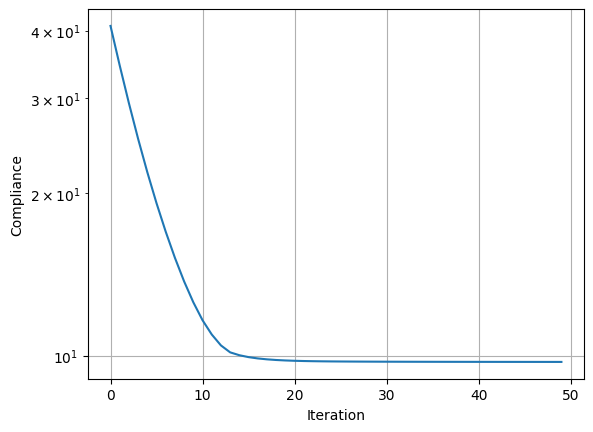

In [4]:
plt.semilogy(history)
plt.xlabel("Iteration")
plt.ylabel("Compliance")
plt.grid()
plt.show()

The optimized lattice is drawn with a bar radius following its cross-sectional area.

In [5]:
lattice.areas = a[-1]
lattice.plot(bcs=False)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…